# 🕷️ UAC Bibliothèque Numérique — Scraper

Ce notebook collecte automatiquement tous les ouvrages de la bibliothèque numérique de l'UAC :
**https://bibliothequenumerique.uaconline.edu.cd**

### Données extraites
| Champ | Description |
|---|---|
| `titre` | Titre de l'ouvrage |
| `auteur` | Auteur(s) |
| `isbn` | Numéro ISBN |
| `domaine` | Domaine académique |
| `description` | Résumé de l'ouvrage |
| `image_url` | URL de la couverture |
| `url_detail` | Lien vers la fiche complète |
| `edition` | Édition (enrichissement) |
| `annee` | Année de publication (enrichissement) |
| `categorie` | Catégorie (Livre, Article, Mémoire...) |

### Résultat
Fichier CSV : `data/uac_bibliotheque.csv`

## 1. Installation des dépendances

In [ ]:
# Installer les bibliothèques nécessaires si pas encore installées
#!pip install requests beautifulsoup4 pandas --quiet

## 2. Imports

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import os
import logging

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s — %(message)s'
)

print("✅ Imports OK")

✅ Imports OK


## 3. Configuration

In [2]:
BASE_URL = "https://bibliothequenumerique.uaconline.edu.cd"

# Tous les domaines du site avec leur identifiant (iddomaine)
DOMAINES = {
    "Sciences Informatiques":                          1,
    "Intelligence Artificielle":                       2,
    "Programmation web":                               3,
    "Sciences de données":                             4,
    "Management":                                      5,
    "Gestion des ressources humaines":                 6,
    "Droit Civil":                                     7,
    "Sciences Agronomiques":                           8,
    "Sciences politiques":                             9,
    "Sciences économiques et de gestion":             10,
    "Sciences juridiques et administratives":         11,
    "Comptabilité et Finance":                        12,
    "Sciences de l'information et de Communication": 13,
    "Programmation mobile":                           14,
    "Programmation":                                  15,
    "Programmation Python":                           16,
    "Réseaux Informatiques":                          17,
    "Sécurité Informatique":                          18,
    "Linguistique":                                   19,
    "Sciences de la psychologie et de l'éducation":  20,
    "Pisciculture & Apiculture":                      21,
    "Electricité-électronique":                       22,
    "Mathématiques":                                  23,
    "Physique":                                       24,
    "Biologie et Chimie":                             25,
    "Sciences et technologie":                        26,
    "Mécanique":                                      27,
    "Dessin":                                         28,
    "Sciences humaines (Philosophie)":                29,
    "Sociologie":                                     30,
    "Sciences sociales":                              31,
    "Histoire de l'Afrique":                          32,
    "Sciences religieuses":                           33,
    "Sciences de la santé":                           34,
    "L'art d'écrire":                                 35,
    "Sciences de la terre":                           39,
    "Internet":                                       40,
    "Doc. ESU":                                       41,
}

# En-tête HTTP pour simuler un navigateur
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

DELAI_SECONDES = 1.0  # délai poli entre chaque requête

print(f"✅ Configuration OK — {len(DOMAINES)} domaines à scraper")

✅ Configuration OK — 38 domaines à scraper


## 4. Fonctions de scraping

### 4.1 — Téléchargement d'une page

In [3]:
def get_page(url: str):
    """
    Télécharge une page web et retourne un objet BeautifulSoup.
    Retourne None en cas d'erreur réseau.
    """
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        resp.raise_for_status()
        return BeautifulSoup(resp.content, "html.parser")
    except requests.RequestException as e:
        logging.warning(f"Erreur chargement {url} : {e}")
        return None

# Test rapide
soup_test = get_page(f"{BASE_URL}/ouvragedomaine.php?iddomaine=2")
print("✅ get_page OK —", "Page chargée" if soup_test else "Échec")

✅ get_page OK — Page chargée


### 4.2 — Extraction des ouvrages d'une page

In [4]:
def extraire_ouvrages_page(soup, domaine: str) -> list:
    """
    Extrait la liste des ouvrages d'une page de domaine.

    Structure HTML du site UAC :
      <h3><a href='etatouvrage.php?idouvrage=N'>Titre</a></h3>
      <li> Auteur: ... </li>
      <li> ISBN: ...  </li>
      <p>  Description </p>
      <img src='...couverture...'>
    """
    ouvrages = []

    liens = soup.select("a[href*='etatouvrage.php?idouvrage=']")
    titres_liens = [l for l in liens if l.find_parent("h3")]

    for lien in titres_liens:
        try:
            titre     = lien.get_text(strip=True)
            url_detail = BASE_URL + "/" + lien["href"].lstrip("/")
            bloc      = lien.find_parent("h3").find_parent()

            # Auteur
            auteur = ""
            for li in bloc.find_all("li"):
                t = li.get_text(strip=True)
                if "Auteur:" in t:
                    auteur = t.replace("Auteur:", "").strip()
                    break

            # ISBN
            isbn = ""
            for li in bloc.find_all("li"):
                t = li.get_text(strip=True)
                if "ISBN:" in t:
                    isbn = t.replace("ISBN:", "").strip()
                    break

            # Description
            description = ""
            para = bloc.find("p")
            if para:
                description = para.get_text(strip=True)

            # Image de couverture
            image_url = ""
            img = bloc.find("img")
            if img and img.get("src"):
                src = img["src"]
                image_url = src if src.startswith("http") else BASE_URL + "/" + src.lstrip("/")

            ouvrages.append({
                "titre":       titre,
                "auteur":      auteur,
                "isbn":        isbn,
                "domaine":     domaine,
                "description": description,
                "image_url":   image_url,
                "url_detail":  url_detail,
            })

        except Exception as e:
            logging.debug(f"Erreur extraction ouvrage : {e}")
            continue

    return ouvrages

# Test sur le domaine IA
if soup_test:
    test_ouvrages = extraire_ouvrages_page(soup_test, "Intelligence Artificielle")
    print(f"✅ extraire_ouvrages_page OK — {len(test_ouvrages)} ouvrages trouvés sur la page test")
    if test_ouvrages:
        print("   Exemple :", test_ouvrages[0]['titre'], "|", test_ouvrages[0]['auteur'])

✅ extraire_ouvrages_page OK — 12 ouvrages trouvés sur la page test
   Exemple : Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems | Aurélien Géron


### 4.3 — Scraping d'un domaine complet (avec pagination)

In [5]:
def scraper_domaine(domaine: str, iddomaine: int) -> list:
    """
    Scrape toutes les pages d'un domaine.
    Gère automatiquement la pagination via le lien 'Suivant'.
    """
    tous_les_ouvrages = []
    page = 1

    while True:
        if page == 1:
            url = f"{BASE_URL}/ouvragedomaine.php?iddomaine={iddomaine}"
        else:
            url = f"{BASE_URL}/ouvragedomaine.php?iddomaine={iddomaine}&page={page}"

        print(f"    → Page {page} : {url}")
        soup = get_page(url)

        if soup is None:
            break

        ouvrages_page = extraire_ouvrages_page(soup, domaine)

        if not ouvrages_page:
            print(f"    → Fin du domaine à la page {page}.")
            break

        tous_les_ouvrages.extend(ouvrages_page)
        print(f"    → {len(ouvrages_page)} ouvrage(s) extraits (total : {len(tous_les_ouvrages)})")

        # Y a-t-il une page suivante ?
        suivant = soup.find("a", string=lambda t: t and "Suivant" in t)
        if not suivant:
            break

        page += 1
        time.sleep(DELAI_SECONDES)

    return tous_les_ouvrages

print("✅ scraper_domaine défini")

✅ scraper_domaine défini


### 4.4 — Enrichissement depuis la fiche détaillée

In [6]:
def scraper_detail_ouvrage(url: str) -> dict:
    """
    Récupère les détails complémentaires depuis la fiche individuelle
    d'un ouvrage (etatouvrage.php) :
    - edition
    - annee
    - categorie (Livre, Article, Mémoire UAC, Autre)
    """
    soup = get_page(url)
    if not soup:
        return {}

    details = {}
    try:
        for li in soup.find_all("li"):
            texte = li.get_text(strip=True)
            if "Edition:" in texte or "Édition:" in texte:
                details["edition"] = texte.split(":", 1)[-1].strip()
            elif "Année:" in texte or "Annee:" in texte:
                details["annee"] = texte.split(":", 1)[-1].strip()
            elif "Catégorie:" in texte or "Categorie:" in texte:
                details["categorie"] = texte.split(":", 1)[-1].strip()
    except Exception as e:
        logging.debug(f"Erreur détail {url} : {e}")

    return details

print("✅ scraper_detail_ouvrage défini")

✅ scraper_detail_ouvrage défini


## 5. Test sur un seul domaine

Avant de lancer le scraping complet, vérifions que tout fonctionne sur le domaine **Intelligence Artificielle**.

In [7]:
print("🧪 Test sur le domaine : Intelligence Artificielle\n")

ouvrages_test = scraper_domaine("Intelligence Artificielle", 2)

df_test = pd.DataFrame(ouvrages_test)
print(f"\n✅ {len(df_test)} ouvrages extraits")
df_test.head()

🧪 Test sur le domaine : Intelligence Artificielle

    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=2
    → 12 ouvrage(s) extraits (total : 12)

✅ 12 ouvrages extraits


,titre,auteur,isbn,domaine,description,image_url,url_detail
0,"Hands-On Machine Learning with Scikit-Learn, K...",Aurélien Géron,978-1-098-12597-4,Intelligence Artificielle,,,https://bibliothequenumerique.uaconline.edu.cd...
1,PATTERN RECOGNITION,"Sergios Theodoridis, Konstantinos Koutroumbas",978-1-59749-272-0,Intelligence Artificielle,,,https://bibliothequenumerique.uaconline.edu.cd...
2,Deep Learning,Ian Goodfellow Yoshua Bengio and Aaron Courville,978-0-262-33737-3,Intelligence Artificielle,,,https://bibliothequenumerique.uaconline.edu.cd...
3,The Elements of Statistical Learning Data Mini...,"Trevor Hastie, Robert Tibshirani, Jerome Friedman",,Intelligence Artificielle,,,https://bibliothequenumerique.uaconline.edu.cd...
4,The Deep Learning Revolution,Terrence J. Sejnowski,,Intelligence Artificielle,,,https://bibliothequenumerique.uaconline.edu.cd...


## 6. Scraping complet — tous les domaines

> ⏱️ **Durée estimée :** 30 à 60 minutes selon la connexion internet (délai poli de 1 s entre chaque requête).
>
> 💡 Si tu veux aller vite, tu peux réduire `DELAI_SECONDES = 0.5` dans la cellule de configuration.

In [8]:
os.makedirs("data", exist_ok=True)
tous_les_ouvrages = []

print(f"🚀 Début du scraping — {len(DOMAINES)} domaines\n")

for domaine, iddomaine in DOMAINES.items():
    print(f"📂 [{iddomaine:02d}] {domaine}")
    ouvrages = scraper_domaine(domaine, iddomaine)
    tous_les_ouvrages.extend(ouvrages)
    print(f"  ✅ Sous-total : {len(tous_les_ouvrages)} ouvrages accumulés\n")
    time.sleep(DELAI_SECONDES)

print(f"\n🎉 Scraping des domaines terminé — {len(tous_les_ouvrages)} ouvrages collectés")

🚀 Début du scraping — 38 domaines

📂 [01] Sciences Informatiques
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=1
    → 12 ouvrage(s) extraits (total : 12)
  ✅ Sous-total : 12 ouvrages accumulés

📂 [02] Intelligence Artificielle
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=2


[2026-09-03 12:05:30,888] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=2 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Max retries exceeded with url: /ouvragedomaine.php?iddomaine=2 (Caused by ConnectTimeoutError(<HTTPSConnection(host='bibliothequenumerique.uaconline.edu.cd', port=443) at 0x11c2a568fe0>, 'Connection to bibliothequenumerique.uaconline.edu.cd timed out. (connect timeout=15)'))


  ✅ Sous-total : 12 ouvrages accumulés

📂 [03] Programmation web
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=3
    → 12 ouvrage(s) extraits (total : 12)
  ✅ Sous-total : 24 ouvrages accumulés

📂 [04] Sciences de données
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=4


[2026-09-03 12:05:53,846] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=4 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Read timed out. (read timeout=15)


  ✅ Sous-total : 24 ouvrages accumulés

📂 [05] Management
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=5
    → 12 ouvrage(s) extraits (total : 12)
  ✅ Sous-total : 36 ouvrages accumulés

📂 [06] Gestion des ressources humaines
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=6


...

  ✅ Sous-total : 252 ouvrages accumulés

📂 [28] Dessin
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=28
    → 6 ouvrage(s) extraits (total : 6)
  ✅ Sous-total : 258 ouvrages accumulés

📂 [29] Sciences humaines (Philosophie)
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=29
    → 12 ouvrage(s) extraits (total : 12)
  ✅ Sous-total : 270 ouvrages accumulés

📂 [30] Sociologie
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=30


[2026-09-03 12:09:31,398] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=30 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Read timed out. (read timeout=15)


  ✅ Sous-total : 270 ouvrages accumulés

📂 [31] Sciences sociales
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=31
    → 12 ouvrage(s) extraits (total : 12)
  ✅ Sous-total : 282 ouvrages accumulés

📂 [32] Histoire de l'Afrique
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=32
    → 12 ouvrage(s) extraits (total : 12)
  ✅ Sous-total : 294 ouvrages accumulés

📂 [33] Sciences religieuses
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=33
    → 12 ouvrage(s) extraits (total : 12)
  ✅ Sous-total : 306 ouvrages accumulés

📂 [34] Sciences de la santé
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=34
    → 12 ouvrage(s) extraits (total : 12)
  ✅ Sous-total : 318 ouvrages accumulés

📂 [35] L'art d'écrire
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=35
    → 12 ouvrage(s) extra

[2026-09-03 12:10:07,868] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=40 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Read timed out. (read timeout=15)


  ✅ Sous-total : 342 ouvrages accumulés

📂 [41] Doc. ESU
    → Page 1 : https://bibliothequenumerique.uaconline.edu.cd/ouvragedomaine.php?iddomaine=41
    → 2 ouvrage(s) extraits (total : 2)
  ✅ Sous-total : 344 ouvrages accumulés


🎉 Scraping des domaines terminé — 344 ouvrages collectés


## 7. Enrichissement des fiches individuelles

Récupère `edition`, `annee` et `categorie` depuis chaque fiche détaillée.

> ⚠️ Cette étape est **optionnelle mais recommandée**. Elle est plus lente car elle visite chaque fiche individuellement. Tu peux la passer en commentaire si tu veux le CSV rapidement.

In [9]:
print(f"🔍 Enrichissement de {len(tous_les_ouvrages)} fiches...\n")

for i, ouvrage in enumerate(tous_les_ouvrages):
    details = scraper_detail_ouvrage(ouvrage["url_detail"])
    ouvrage.update(details)

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(tous_les_ouvrages)} ouvrages enrichis...")

    time.sleep(DELAI_SECONDES * 0.5)

print("\n✅ Enrichissement terminé")

🔍 Enrichissement de 344 fiches...



[2026-09-03 12:10:51,075] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=4292 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Max retries exceeded with url: /etatouvrage.php?idouvrage=4292 (Caused by ConnectTimeoutError(<HTTPSConnection(host='bibliothequenumerique.uaconline.edu.cd', port=443) at 0x11c6aca6cf0>, 'Connection to bibliothequenumerique.uaconline.edu.cd timed out. (connect timeout=15)'))
[2026-09-03 12:11:38,971] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=3973 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Max retries exceeded with url: /etatouvrage.php?idouvrage=3973 (Caused by ConnectTimeoutError(<HTTPSConnection(host='bibliothequenumerique.uaconline.edu.cd', port=443) at 0x11c6ac3ef00>, 'Connection to bibliothequenumerique.uaconline.edu.cd timed out. (connect timeout=15)'))
[2026-09-03 12:12:17,800

  50/344 ouvrages enrichis...


[2026-09-03 12:17:56,510] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=3999 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Max retries exceeded with url: /etatouvrage.php?idouvrage=3999 (Caused by ConnectTimeoutError(<HTTPSConnection(host='bibliothequenumerique.uaconline.edu.cd', port=443) at 0x11c6a6b4bc0>, 'Connection to bibliothequenumerique.uaconline.edu.cd timed out. (connect timeout=15)'))
[2026-09-03 12:18:15,976] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=3907 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Read timed out. (read timeout=15)
[2026-09-03 12:18:53,056] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=4011 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Read timed out. (read timeout=15)
[2026-09-03 12:19:57

  100/344 ouvrages enrichis...


...

  200/344 ouvrages enrichis...


[2026-09-03 12:38:55,268] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=2861 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Read timed out. (read timeout=15)
[2026-09-03 12:39:11,449] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=3818 : ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
[2026-09-03 12:39:54,617] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=3666 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Max retries exceeded with url: /etatouvrage.php?idouvrage=3666 (Caused by ConnectTimeoutError(<HTTPSConnection(host='bibliothequenumerique.uaconline.edu.cd', port=443) at 0x11c6aca4950>, 'Connection to bibliothequenumerique.uaconline.edu.cd timed out. (connect timeout=15)'))
[2026-09-03 12:40:16,789] WARNING — Err

  250/344 ouvrages enrichis...


[2026-09-03 12:45:54,167] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=313 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Read timed out. (read timeout=15)
[2026-09-03 12:46:15,323] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=160 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Read timed out. (read timeout=15)
[2026-09-03 12:46:53,744] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=4033 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Read timed out. (read timeout=15)
[2026-09-03 12:47:22,497] WARNING — Erreur chargement https://bibliothequenumerique.uaconline.edu.cd/etatouvrage.php?idouvrage=4029 : HTTPSConnectionPool(host='bibliothequenumerique.uaconline.edu.cd', port=443): Max retries exceeded with url: /etatouvrage.php?idou


✅ Enrichissement terminé


## 8. Nettoyage et sauvegarde CSV

In [10]:
df = pd.DataFrame(tous_les_ouvrages)

print("📊 Aperçu avant nettoyage :")
print(f"  Lignes    : {len(df)}")
print(f"  Colonnes  : {list(df.columns)}")
print(f"  Valeurs nulles :\n{df.isnull().sum()}\n")

# Suppression des doublons (même titre + même auteur)
avant = len(df)
df.drop_duplicates(subset=["titre", "auteur"], inplace=True)
df.reset_index(drop=True, inplace=True)
apres = len(df)
print(f"🧹 Doublons supprimés : {avant - apres}")

# Sauvegarde
output_path = "data/uac_bibliotheque.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\n✅ CSV sauvegardé : '{output_path}'")
print(f"   {len(df)} ouvrages | {len(df.columns)} colonnes")

📊 Aperçu avant nettoyage :
  Lignes    : 344
  Colonnes  : ['titre', 'auteur', 'isbn', 'domaine', 'description', 'image_url', 'url_detail']
  Valeurs nulles :
titre          0
auteur         0
isbn           0
domaine        0
description    0
image_url      0
url_detail     0
dtype: int64

🧹 Doublons supprimés : 1

✅ CSV sauvegardé : 'data/uac_bibliotheque.csv'
   343 ouvrages | 7 colonnes


## 9. Exploration du dataset collecté

In [11]:
# Aperçu général
df.head(10)

,titre,auteur,isbn,domaine,description,image_url,url_detail
0,Software Requirements,"Karl Wiegers, Joey Beatty",978-0-7356-7966-5,Sciences Informatiques,,,https://bibliothequenumerique.uaconline.edu.cd...
1,"Database Systems Design, Implementation, and M...","Carlos Coronel, Steven Morris, Peter Rob",978-1-111-96960-8,Sciences Informatiques,,,https://bibliothequenumerique.uaconline.edu.cd...
2,Operating Systems Three Easy Pieces,"Remzi H. Arpaci-Dusseau, Andrea C Arpaci-Dusseau",9781985086593,Sciences Informatiques,,,https://bibliothequenumerique.uaconline.edu.cd...
3,Gérer un parc informatique une initiation pra...,Le Bel Pierre,2-922889-08-4,Sciences Informatiques,,,https://bibliothequenumerique.uaconline.edu.cd...
4,Systèmes d’information géographique,Yves Auda,978-2-10-084196-7,Sciences Informatiques,,,https://bibliothequenumerique.uaconline.edu.cd...
5,Stratégie et pilotage des systèmes d’information,Renaud CORNU-EMIEUX & Hugues POISSONNIER,978-2-10-054537-7,Sciences Informatiques,,,https://bibliothequenumerique.uaconline.edu.cd...
6,optimisez votre système d'information,Oihab Allal-Chérif et Olivier Dupouët,978-2-918935-08-7,Sciences Informatiques,,,https://bibliothequenumerique.uaconline.edu.cd...
7,GEOPOLITIQUE DES DONNEES NUMERIQUES,Amaël Cattaruzza,979-10-318-0348-7,Sciences Informatiques,,,https://bibliothequenumerique.uaconline.edu.cd...
8,Supériorité numérique,Avon Gale,978-2-37676-318-5,Sciences Informatiques,,,https://bibliothequenumerique.uaconline.edu.cd...
9,SOBRIÉTÉ NUMÉRIQUE,FRÉDÉRIC BORDAGE,978-2-283-03271-8,Sciences Informatiques,,,https://bibliothequenumerique.uaconline.edu.cd...


In [12]:
# Répartition par domaine
print("📚 Nombre d'ouvrages par domaine :\n")
repartition = df['domaine'].value_counts()
print(repartition.to_string())

📚 Nombre d'ouvrages par domaine :

domaine
Sciences Informatiques                           12
Programmation web                                12
Management                                       12
Droit Civil                                      12
Sciences Agronomiques                            12
Sciences politiques                              12
Sciences économiques et de gestion               12
Sciences juridiques et administratives           12
Comptabilité et Finance                          12
Sciences de l'information et de Communication    12
Programmation                                    12
Programmation Python                             12
Réseaux Informatiques                            12
Sécurité Informatique                            12
Linguistique                                     12
Pisciculture & Apiculture                        12
Electricité-électronique                         12
Mathématiques                                    12
Physique             

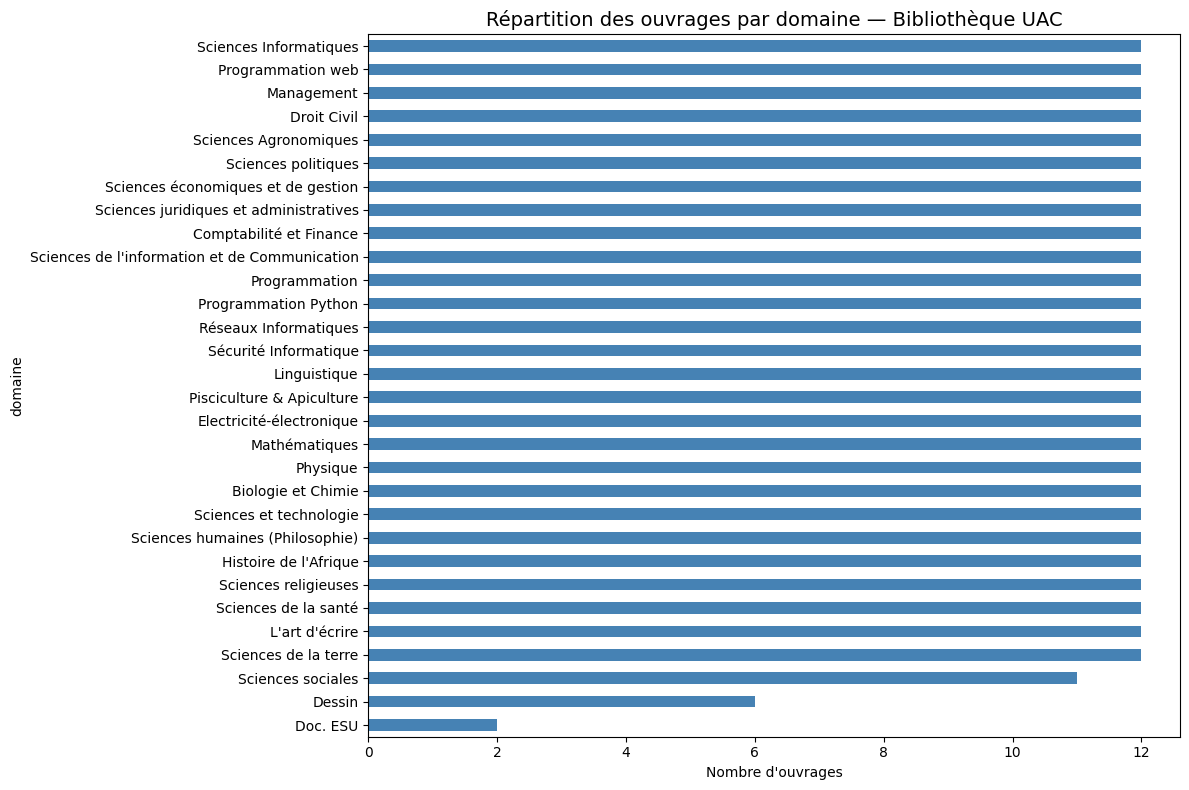

📊 Graphique sauvegardé : data/repartition_domaines.png


In [13]:
import matplotlib.pyplot as plt

# Graphique de répartition
fig, ax = plt.subplots(figsize=(12, 8))
repartition.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Répartition des ouvrages par domaine — Bibliothèque UAC', fontsize=14)
ax.set_xlabel('Nombre d\'ouvrages')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('data/repartition_domaines.png', dpi=150)
plt.show()
print("📊 Graphique sauvegardé : data/repartition_domaines.png")

In [14]:
# Statistiques générales
print("=" * 50)
print("📈 STATISTIQUES FINALES")
print("=" * 50)
print(f"Total ouvrages       : {len(df)}")
print(f"Domaines couverts    : {df['domaine'].nunique()}")
print(f"Ouvrages avec ISBN   : {(df['isbn'] != '').sum()}")
print(f"Ouvrages avec image  : {(df['image_url'] != '').sum()}")
print(f"Ouvrages avec desc.  : {(df['description'] != '').sum()}")
if 'categorie' in df.columns:
    print(f"\nCatégories :")
    print(df['categorie'].value_counts().to_string())

📈 STATISTIQUES FINALES
Total ouvrages       : 343
Domaines couverts    : 30
Ouvrages avec ISBN   : 264
Ouvrages avec image  : 0
Ouvrages avec desc.  : 0
